Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/test.csv')

In [ ]:
!mkdir data
!mkdir data/train
!mkdir data/test


Preprocessing

In [ ]:
import cv2
from tqdm import tqdm
df_train_processed = pd.DataFrame(columns=['id', 'label'])

ids = []
for i in tqdm(range(len(df_train))):
    img = df_train.iloc[i, 1:].values.reshape(28, 28)
    img = cv2.imwrite('data/train/{}.png'.format(i), img)
    ids.append('{}.png'.format(i))
df_train_processed['id'] = ids
df_train_processed['label'] = df_train['label'].astype(str)


100%|██████████| 42000/42000 [00:10<00:00, 4041.77it/s]


<Axes: ylabel='count'>

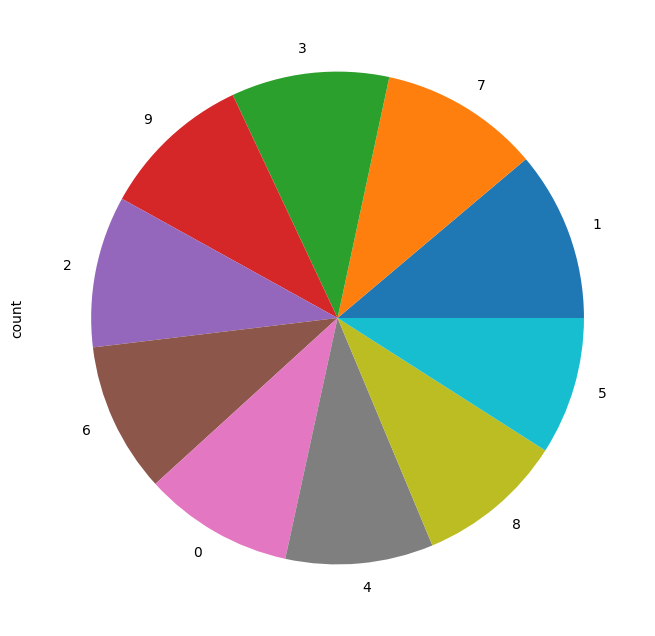

In [ ]:
plt.figure(figsize=(16, 8))
df_train_processed['label'].value_counts().plot(kind='pie')

In [ ]:
import cv2
from tqdm import tqdm
df_test_processed = pd.DataFrame(columns=['id', 'label'])

ids = []
for i in tqdm(range(len(df_test))):
    img = df_test.iloc[i, :].values.reshape(28, 28)
    img = cv2.imwrite('data/test/{}.png'.format(i), img)
    ids.append('{}.png'.format(i))
df_test_processed['id'] = ids


100%|██████████| 28000/28000 [00:05<00:00, 4801.75it/s]


In [ ]:
df_train_processed.shape,df_test_processed.shape

((42000, 2), (28000, 2))

In [ ]:
from keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1/255., validation_split=0.2, horizontal_flip=False, height_shift_range=0.2, width_shift_range=0.1, rotation_range=5)
test_gen = ImageDataGenerator(rescale=1/255.)
img_size = (224, 224)
batch_size = 200
train_generator = train_gen.flow_from_dataframe(dataframe=df_train_processed,
                                               directory='data/train',
                                               x_col='id',
                                               y_col='label',
                                               batch_size=batch_size,
                                               class_mode='categorical',
                                               target_size=img_size,
                                               subset='training')
valid_generator = train_gen.flow_from_dataframe(dataframe=df_train_processed,
                                                  directory="data/train",
                                                  x_col="id",
                                                  y_col="label",
                                                  batch_size=batch_size,
                                                  class_mode="categorical",
                                                  target_size=img_size,
                                                  subset='validation')
test_generator = test_gen.flow_from_dataframe(dataframe=df_test_processed,
                                                  directory = "data/test",
                                                  x_col="id",
                                                  target_size=img_size,
                                                  batch_size=1,
                                                  shuffle=False,
                                                  class_mode=None)


Found 33600 validated image filenames belonging to 10 classes.
Found 8400 validated image filenames belonging to 10 classes.
Found 28000 validated image filenames.


Model - DenseNet121

In [ ]:
import keras
model=keras.models.load_model('/content/drive/MyDrive/mnistdensenet.keras')
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 112, 112, 64)         9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1/conv[0][0]']      

In [ ]:
img, label = train_generator.next()

In [ ]:
val, label = valid_generator.next()

In [ ]:
val.shape

(200, 224, 224, 3)

In [ ]:
pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 8.7 MB/s eta 0:00:00


Gradient Shap


In [ ]:
import shap
# since we have two inputs we pass a list of inputs to the explainer
e = shap.GradientExplainer(model,img)
# we explain the model's predictions on the first three samples of the test set
shap_values = e.shap_values(val[:100])

/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [ ]:
shapgradvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(224):
    r1=shap_values[k][i]
    for j in range(224):
        rw.append(r1[j][0][0])
  shapgradvec.append(rw)

In [ ]:
len(shapgradvec[4])

50176

In [ ]:
shapgradvec_pos=[] #only positive scores
#deepvec_pos=[] #only positive scores
for k in range(100):
  shapgrad_score_zero=[0 if i<0 else i for i in shapgradvec[k]]
  shapgradvec_pos.append(shapgrad_score_zero)
  #deepshap_score_zero= [0 if i<0 else i for i in deepvec[k]]
  #deepvec_pos.append(deepshap_score_zero)

Partition Shap


In [ ]:
def f(x):
    temp=x.copy()
    p=model(temp)
    class_name=np.argmax(p,axis=1)
    #return class_name
    return p
class_names=[0,1,2,3,4,5,6,7,8,9]

In [ ]:
import shap
masker = shap.maskers.Image("blur(28,28)", img[0].shape)
explainer = shap.Explainer(f, masker,output_names=class_names)

In [ ]:
part_shap_values=explainer(val[0:100],max_evals=5000,batch_size=50,outputs=shap.Explanation.argsort.flip[:4])

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 3/100 [01:05<25:04, 15.51s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  99%|█████████▉| 99/100 [49:38<00:29, 29.93s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [50:08<00:00, 29.87s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [50:38, 30.38s/it]


In [ ]:
pip install tf_keras_vis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 1.8 MB/s eta 0:00:00


In [ ]:
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

replace2linear = ReplaceToLinear()

# Instead of using the ReplaceToLinear instance above,
# you can also define the function from scratch as follows:
def model_modifier_function(cloned_model):
    cloned_model.layers[-1].activation = tf.keras.activations.linear

In [ ]:
from tf_keras_vis.utils.scores import CategoricalScore

#score = CategoricalScore([0,1,2,3,4,5,6,7,8,9])

# Instead of using CategoricalScore object,
# you can also define the function from scratch as follows:
def score_function(output):
    # The `output` variable refers to the output of the model,
    # so, in this case, `output` shape is `(3, 1000)` i.e., (samples, classes).
    return (output[:,])

GradCAM

In [ ]:
from matplotlib import cm
from tf_keras_vis.gradcam import Gradcam

# Create Gradcam object
gradcam = Gradcam(model,
                  model_modifier=replace2linear,
                  clone=True)

# Generate heatmap with GradCAM
cam = gradcam(score_function,
              val[0:100],
              penultimate_layer=-1)

## Since v0.6.0, calling `normalize()` is NOT necessary.
# cam = normalize(cam)

In [ ]:
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus

# Create GradCAM++ object
gradcampp = GradcamPlusPlus(model,
                          model_modifier=replace2linear,
                          clone=True)

# Generate heatmap with GradCAM++
campp = gradcampp(score_function,
              val[0:100],
              penultimate_layer=-1)

## Since v0.6.0, calling `normalize()` is NOT necessary.
# cam = normalize(cam)

In [ ]:
partvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(224):
    r1=part_shap_values[k][i]
    for j in range(224):
        rw.append(r1.values[j][0][0])
  partvec.append(rw)

In [ ]:
partvec[99] #vector containing partition scores of 100 images

[-3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.6597571836239624e-10,
 -3.65975718

In [ ]:
partvec_pos=[] #only positive scores
#deepvec_pos=[] #only positive scores
for k in range(100):
  partition_score_zero=[0 if i<0 else i for i in partvec[k]]
  partvec_pos.append(partition_score_zero)
  #deepshap_score_zero= [0 if i<0 else i for i in deepvec[k]]
  #deepvec_pos.append(deepshap_score_zero)

In [ ]:
gradvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(224):
    r1=cam[k][i]
    for j in range(224):
      rw.append(r1[j])
  gradvec.append(rw)

In [ ]:
gradppvec=[]
for k in range(100):
  rw=[]
  r1=[]
  for i in range(224):
    r1=campp[k][i]
    for j in range(224):
      rw.append(r1[j])
  gradppvec.append(rw)

In [ ]:
shapgradvec_pixel=[]
partvec_pixel=[]
gradvec_pixel=[]
gradppvec_pixel=[]

for k in range(100): #partition
  rw_temp=shapgradvec_pos[k]
  revid=np.argsort(rw_temp)[::-1][:50176]
  shapgradvec_pixel.append(revid)


for k in range(100): #partition
  rw_temp=partvec_pos[k]
  revid=np.argsort(rw_temp)[::-1][:50176]
  partvec_pixel.append(revid)

In [ ]:
partvec_pixel[96] #partition

array([35563, 35567, 35569, ..., 26956, 26957, 22132])

In [ ]:
for k in range(100): #gradcam
  rw_temp=gradvec[k]
  revid=np.argsort(rw_temp)[::-1][:50176]
  gradvec_pixel.append(revid)

In [ ]:
gradvec_pixel[99]

array([  149,   150,   151, ..., 33446, 33445,     0])

In [ ]:
gradppvec_pixel=[]
for k in range(100): #gradcam++
  rw_temp=gradppvec[k]
  revid=np.argsort(rw_temp)[::-1][:50176]
  gradppvec_pixel.append(revid)

In [ ]:
gradppvec_pixel[99]

array([16725, 16949, 16726, ..., 50009, 50010,     0])

In [ ]:
#r12,r13,r14,r23,r24,r34
#1-gradientshap 2-partition 3-gradcam 4-gradcam++
import numpy as np
import math

MC+BC Metric

In [ ]:
def multiplefull(a,b,c,d): #a-gradientshap, b-partition, c-gradcam, d-gradcam++
  ans=[]
  for k in range(100):
    temp=[]
    r12=np.corrcoef(a[k],b[k])
    r13=np.corrcoef(a[k],c[k])
    r14=np.corrcoef(a[k],d[k])
    r23=np.corrcoef(b[k],c[k])
    r24=np.corrcoef(b[k],d[k])
    r34=np.corrcoef(c[k],d[k])
    #print(r13[0][1],r34[0][1])
    r12_3=(r12[0][1]-(r13[0][1]*r23[0][1]))/(math.sqrt((1-r13[0][1]*r13[0][1])*(1-r23[0][1]*r23[0][1])))
    r14_3=(r14[0][1]-(r13[0][1]*r34[0][1]))/(math.sqrt((1-r13[0][1]*r13[0][1])*(1-r34[0][1]*r34[0][1])))
    r14_2=(r14[0][1]-(r12[0][1]*r24[0][1]))/(math.sqrt((1-r12[0][1]*r12[0][1])*(1-r24[0][1]*r24[0][1])))
    r24_3=(r24[0][1]-(r23[0][1]*r34[0][1]))/(math.sqrt((1-r23[0][1]*r23[0][1])*(1-r34[0][1]*r34[0][1])))
    r13_2=(r13[0][1]-(r12[0][1]*r23[0][1]))/(math.sqrt((1-r12[0][1]*r12[0][1])*(1-r23[0][1]*r23[0][1])))
    r34_2=(r34[0][1]-(r23[0][1]*r24[0][1]))/(math.sqrt((1-r23[0][1]*r23[0][1])*(1-r24[0][1]*r24[0][1])))
    #print(r14[0][1])
    #print((r13[0][1]*r34[0][1]))
    #print(math.sqrt((1-r13[0][1]*r13[0][1])*(1-r34[0][1]*r34[0][1])))
    #print(r12_3,r14_3,r14_2,r24_3,r13_2,r34_2)
    r12_34=(r12_3-r14_3*r24_3)/(math.sqrt((1-r14_3*r14_3)*(1-r24_3*r24_3)))
    r13_24=(r13_2-r14_2*r34_2)/(math.sqrt((1-r14_2*r14_2)*(1-r34_2*r34_2)))
    r14_23=(r14_2-r13_2*r34_2)/(math.sqrt((1-r13_2*r13_2)*(1-r34_2*r34_2)))
    #print(r12_34,r13_24,r14_23)
    R1_234=math.sqrt(1-(1-r14[0][1]*r14[0][1])*(1-r12_3*r12_3)*(1-r12_34*r12_34))
    R2_134=math.sqrt(1-(1-r24[0][1]*r24[0][1])*(1-r12_3*r12_3)*(1-r12_34*r12_34))
    R3_124=math.sqrt(1-(1-r34[0][1]*r34[0][1])*(1-r13_2*r13_2)*(1-r13_24*r13_24))
    R4_123=math.sqrt(1-(1-r34[0][1]*r34[0][1])*(1-r14_2*r14_2)*(1-r14_23*r14_23))
    #print(R1_234,R2_134,R3_124,R4_123)
    temp.append(R1_234)
    temp.append(R2_134)
    temp.append(R3_124)
    temp.append(R4_123)
    ans.append(temp)
  return ans

In [ ]:
out=multiplefull(shapgradvec_pixel,partvec_pixel,gradvec_pixel,gradppvec_pixel)
out

[[0.6160619477525677,
  0.6587416649467752,
  0.5411923878549507,
  0.4495491858177075],
 [0.14783136812719563,
  0.14704185510992285,
  0.17477760291666075,
  0.11259033065666688],
 [0.3545845032036333,
  0.3515207563553999,
  0.4427343290315167,
  0.44998996245137507],
 [0.16507108113768185,
  0.08593600517105109,
  0.4092035564310608,
  0.4462730825352242],
 [0.10386041560083323,
  0.12053750650510747,
  0.05807192303138798,
  0.01707921318510356],
 [0.04083954950410831,
  0.03831670478813662,
  0.5776610220914915,
  0.08302138788617697],
 [0.46759858887880285,
  0.4327999060569007,
  0.22259267640263838,
  0.3079229292480157],
 [0.31098000555326405,
  0.2970290658585633,
  0.4802938465325352,
  0.38202889686644054],
 [0.4141779967089258,
  0.41224025182843477,
  0.3937653602469833,
  0.18748682987091597],
 [0.18505952067795534,
  0.200372595407082,
  0.5853453556103274,
  0.07366664328247623],
 [0.14439181208343926,
  0.11255737416234617,
  0.13337242675731686,
  0.2047400704142696

In [ ]:
iout=[]
for i in range(100):
  x=np.argsort(out[i])[::-1][:51076]
  iout.append(x)
iout

[array([1, 0, 2, 3]),
 array([2, 0, 1, 3]),
 array([3, 2, 0, 1]),
 array([3, 2, 0, 1]),
 array([1, 0, 2, 3]),
 array([2, 3, 0, 1]),
 array([0, 1, 3, 2]),
 array([2, 3, 0, 1]),
 array([0, 1, 2, 3]),
 array([2, 1, 0, 3]),
 array([3, 0, 2, 1]),
 array([1, 2, 3, 0]),
 array([0, 1, 2, 3]),
 array([3, 2, 0, 1]),
 array([2, 3, 1, 0]),
 array([0, 1, 2, 3]),
 array([1, 2, 0, 3]),
 array([1, 2, 0, 3]),
 array([3, 2, 0, 1]),
 array([2, 3, 0, 1]),
 array([1, 0, 2, 3]),
 array([2, 3, 1, 0]),
 array([0, 3, 1, 2]),
 array([2, 3, 1, 0]),
 array([0, 1, 2, 3]),
 array([0, 1, 3, 2]),
 array([0, 1, 3, 2]),
 array([0, 1, 3, 2]),
 array([2, 3, 0, 1]),
 array([1, 0, 2, 3]),
 array([2, 3, 1, 0]),
 array([2, 3, 0, 1]),
 array([0, 1, 3, 2]),
 array([1, 0, 2, 3]),
 array([3, 2, 0, 1]),
 array([1, 0, 3, 2]),
 array([2, 3, 1, 0]),
 array([0, 1, 2, 3]),
 array([1, 0, 2, 3]),
 array([2, 0, 1, 3]),
 array([1, 2, 0, 3]),
 array([0, 3, 1, 2]),
 array([3, 2, 0, 1]),
 array([2, 1, 3, 0]),
 array([2, 3, 1, 0]),
 array([1,

In [ ]:
#making 0as 1, 1as 2 ...
iout1=[]
for i in range(100):
  temp=iout[i]
  t=[x+1 for x in temp]
  iout1.append(t)
iout1

[[2, 1, 3, 4],
 [3, 1, 2, 4],
 [4, 3, 1, 2],
 [4, 3, 1, 2],
 [2, 1, 3, 4],
 [3, 4, 1, 2],
 [1, 2, 4, 3],
 [3, 4, 1, 2],
 [1, 2, 3, 4],
 [3, 2, 1, 4],
 [4, 1, 3, 2],
 [2, 3, 4, 1],
 [1, 2, 3, 4],
 [4, 3, 1, 2],
 [3, 4, 2, 1],
 [1, 2, 3, 4],
 [2, 3, 1, 4],
 [2, 3, 1, 4],
 [4, 3, 1, 2],
 [3, 4, 1, 2],
 [2, 1, 3, 4],
 [3, 4, 2, 1],
 [1, 4, 2, 3],
 [3, 4, 2, 1],
 [1, 2, 3, 4],
 [1, 2, 4, 3],
 [1, 2, 4, 3],
 [1, 2, 4, 3],
 [3, 4, 1, 2],
 [2, 1, 3, 4],
 [3, 4, 2, 1],
 [3, 4, 1, 2],
 [1, 2, 4, 3],
 [2, 1, 3, 4],
 [4, 3, 1, 2],
 [2, 1, 4, 3],
 [3, 4, 2, 1],
 [1, 2, 3, 4],
 [2, 1, 3, 4],
 [3, 1, 2, 4],
 [2, 3, 1, 4],
 [1, 4, 2, 3],
 [4, 3, 1, 2],
 [3, 2, 4, 1],
 [3, 4, 2, 1],
 [2, 4, 3, 1],
 [3, 1, 2, 4],
 [3, 4, 1, 2],
 [4, 3, 1, 2],
 [4, 3, 1, 2],
 [3, 4, 2, 1],
 [2, 1, 3, 4],
 [3, 1, 2, 4],
 [3, 4, 2, 1],
 [2, 1, 4, 3],
 [2, 1, 3, 4],
 [1, 2, 4, 3],
 [3, 4, 2, 1],
 [3, 2, 1, 4],
 [4, 1, 3, 2],
 [1, 2, 4, 3],
 [3, 4, 1, 2],
 [3, 2, 1, 4],
 [3, 2, 1, 4],
 [3, 4, 1, 2],
 [1, 2, 3, 4],
 [3, 4, 1,

In [ ]:
def borda_count(votes):
    num_candidates = len(votes[0])
    scores = {candidate: 0 for candidate in range(1, num_candidates + 1)}

    for ballot in votes:
        for index, candidate in enumerate(ballot):
            scores[candidate] += num_candidates - index - 1

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores

In [ ]:
ballots=iout1
result = borda_count(ballots)
print("Borda Count Result:")
for candidate, score in result:
    print(f"Candidate {candidate}: {score} points")

Borda Count Result:
Candidate 3: 184 points
Candidate 1: 147 points
Candidate 2: 140 points
Candidate 4: 129 points


In [ ]:
#final ranking - Multiple correlation
#based borda count ranking
borda_rank=[]
for candidate, score in result:
    borda_rank.append(candidate)
borda_rank

[3, 1, 2, 4]

In [ ]:
#Borda method

In [ ]:
shapgradpixel1 = [x+1 for x in shapgradvec_pixel]
partpixel1=[x+1 for x in partvec_pixel]
gradpixel1=[x+1 for x in gradvec_pixel]
gradpppixel1=[x+1 for x in gradppvec_pixel]

BC Metric

In [ ]:
def calculateborda(a,b,c,d):
  bordarank=[]
  for k in range(100):
    ballot=[]
    ballot.append(a[k])
    ballot.append(b[k])
    ballot.append(c[k])
    ballot.append(d[k])
    print(ballot)
    res=borda_count(ballot)
    borda_rank=[]
    for candidate, score in res:
      borda_rank.append(candidate) #single instance
    bordarank.append(borda_rank)
  return bordarank #for 100 samples

In [ ]:
bordarank=calculateborda(shapgradpixel1,partpixel1,gradpixel1,gradpppixel1)
bordarank

[array([26150, 25925, 25700, ..., 27889, 27890,     1]), array([21384, 21379, 21155, ..., 12878, 12877,     1]), array([  150,   149,   151, ..., 33447, 33446,     1]), array([16949, 16725, 16950, ...,  4717,  4716,     1])]
[array([32798, 33022, 32574, ..., 30541, 30542,     1]), array([31865, 32773, 32762, ..., 15645, 15646, 25088]), array([ 8364,  8365,  8366, ..., 33447, 33446,     1]), array([24939, 24938, 24937, ..., 28873, 28874,     1])]
[array([27158, 27154, 27378, ..., 28198, 28199,     1]), array([23792, 24015, 23799, ..., 20057, 20058, 22663]), array([ 8363,  8362,  8361, ..., 33447, 33446, 25088]), array([16875, 16651, 16876, ..., 44437, 44438, 50176])]
[array([21832, 22280, 22056, ..., 28228, 28229,     1]), array([15602, 15603, 14706, ...,  1924,  1923, 46447]), array([  149,   150,   148, ..., 33447, 33446,     1]), array([16689, 16690, 16913, ..., 44429, 44428,     1])]
[array([22127, 22119, 21451, ..., 28161, 28162,     1]), array([23458, 22791, 22568, ..., 37672, 376

[[15843,
  15844,
  16068,
  16070,
  16067,
  15846,
  16069,
  15845,
  16071,
  15847,
  16064,
  16294,
  16292,
  16063,
  20091,
  16295,
  16293,
  16291,
  20092,
  19868,
  20093,
  19869,
  15839,
  16062,
  20094,
  15848,
  19867,
  20095,
  16060,
  19644,
  16059,
  19645,
  20096,
  16518,
  16516,
  16284,
  16519,
  19879,
  16283,
  16517,
  16515,
  19655,
  20097,
  19870,
  20045,
  19878,
  15835,
  16061,
  16286,
  20317,
  20044,
  16065,
  16508,
  19597,
  16507,
  19654,
  20103,
  20717,
  20318,
  20102,
  20038,
  16520,
  20042,
  20039,
  20054,
  21391,
  16285,
  16732,
  16741,
  22123,
  16296,
  20326,
  16742,
  21830,
  20043,
  22124,
  19821,
  20041,
  21832,
  21829,
  20037,
  22121,
  20328,
  21382,
  21834,
  20327,
  16740,
  21833,
  20040,
  16743,
  21384,
  20321,
  19643,
  21836,
  16511,
  22054,
  22125,
  20053,
  21158,
  22053,
  21160,
  22122,
  19607,
  20055,
  20493,
  21388,
  20939,
  19831,
  21385,
  16288,
  19820,
 

In [ ]:
def bordarankcorr(a,b,c,d,borda):
  bordarank_allimages=[]
  for k in range(100):
    temp=[]
    a_borda=np.corrcoef(a[k],borda[k])
    b_borda=np.corrcoef(b[k],borda[k]) #part vs borda
    c_borda=np.corrcoef(c[k],borda[k])  #grad vs borda
    d_borda=np.corrcoef(d[k],borda[k]) #gradpp vs borda
    temp.append(a_borda[0][1])
    temp.append(b_borda[0][1])
    temp.append(c_borda[0][1])
    temp.append(d_borda[0][1])
    t=np.argsort(temp)[::-1][:4]
    bordarank_allimages.append(t)
  return bordarank_allimages

In [ ]:
borda_allimages=bordarankcorr(shapgradpixel1,partpixel1,gradpixel1,gradpppixel1,bordarank)
borda_allimages

[array([2, 3, 0, 1]),
 array([2, 3, 0, 1]),
 array([2, 3, 1, 0]),
 array([2, 3, 0, 1]),
 array([1, 0, 2, 3]),
 array([2, 0, 3, 1]),
 array([2, 3, 0, 1]),
 array([2, 3, 0, 1]),
 array([1, 2, 0, 3]),
 array([3, 1, 0, 2]),
 array([2, 1, 3, 0]),
 array([3, 2, 0, 1]),
 array([2, 3, 1, 0]),
 array([3, 2, 0, 1]),
 array([1, 0, 3, 2]),
 array([2, 0, 1, 3]),
 array([3, 2, 1, 0]),
 array([2, 0, 3, 1]),
 array([2, 0, 3, 1]),
 array([2, 3, 0, 1]),
 array([3, 2, 0, 1]),
 array([2, 0, 3, 1]),
 array([2, 3, 0, 1]),
 array([2, 0, 3, 1]),
 array([1, 2, 0, 3]),
 array([2, 3, 0, 1]),
 array([2, 1, 0, 3]),
 array([2, 0, 3, 1]),
 array([2, 3, 1, 0]),
 array([2, 1, 3, 0]),
 array([2, 3, 0, 1]),
 array([2, 3, 1, 0]),
 array([2, 0, 3, 1]),
 array([1, 3, 2, 0]),
 array([3, 2, 1, 0]),
 array([2, 3, 0, 1]),
 array([2, 3, 1, 0]),
 array([2, 3, 1, 0]),
 array([2, 3, 0, 1]),
 array([1, 2, 3, 0]),
 array([2, 3, 0, 1]),
 array([3, 2, 0, 1]),
 array([2, 3, 1, 0]),
 array([3, 2, 1, 0]),
 array([3, 2, 1, 0]),
 array([3,

In [ ]:
n0=n1=n2=n3=0
for i in range(100):
  if borda_allimages[i][0]==0:
    n0+=1
  elif borda_allimages[i][0]==1:
    n1+=1
  elif borda_allimages[i][0]==2:
    n2+=1
  else:
    n3+=1
print(n0,n1,n2,n3)

0 9 68 23


In [ ]:
#making 0as 1, 1as 2 ...
iout1=[]
for i in range(100):
  temp=borda_allimages[i]
  t=[x+1 for x in temp]
  iout1.append(t)
iout1

[[3, 4, 1, 2],
 [3, 4, 1, 2],
 [3, 4, 2, 1],
 [3, 4, 1, 2],
 [2, 1, 3, 4],
 [3, 1, 4, 2],
 [3, 4, 1, 2],
 [3, 4, 1, 2],
 [2, 3, 1, 4],
 [4, 2, 1, 3],
 [3, 2, 4, 1],
 [4, 3, 1, 2],
 [3, 4, 2, 1],
 [4, 3, 1, 2],
 [2, 1, 4, 3],
 [3, 1, 2, 4],
 [4, 3, 2, 1],
 [3, 1, 4, 2],
 [3, 1, 4, 2],
 [3, 4, 1, 2],
 [4, 3, 1, 2],
 [3, 1, 4, 2],
 [3, 4, 1, 2],
 [3, 1, 4, 2],
 [2, 3, 1, 4],
 [3, 4, 1, 2],
 [3, 2, 1, 4],
 [3, 1, 4, 2],
 [3, 4, 2, 1],
 [3, 2, 4, 1],
 [3, 4, 1, 2],
 [3, 4, 2, 1],
 [3, 1, 4, 2],
 [2, 4, 3, 1],
 [4, 3, 2, 1],
 [3, 4, 1, 2],
 [3, 4, 2, 1],
 [3, 4, 2, 1],
 [3, 4, 1, 2],
 [2, 3, 4, 1],
 [3, 4, 1, 2],
 [4, 3, 1, 2],
 [3, 4, 2, 1],
 [4, 3, 2, 1],
 [4, 3, 2, 1],
 [4, 3, 2, 1],
 [3, 4, 2, 1],
 [3, 4, 1, 2],
 [4, 3, 1, 2],
 [4, 3, 1, 2],
 [3, 4, 1, 2],
 [3, 1, 4, 2],
 [4, 2, 3, 1],
 [3, 4, 1, 2],
 [3, 2, 1, 4],
 [3, 4, 1, 2],
 [2, 4, 1, 3],
 [4, 3, 2, 1],
 [3, 2, 1, 4],
 [3, 1, 4, 2],
 [3, 2, 1, 4],
 [4, 2, 1, 3],
 [3, 1, 4, 2],
 [2, 3, 4, 1],
 [4, 1, 3, 2],
 [3, 1, 4, 2],
 [3, 4, 1,

In [ ]:
ballots_final=iout1
result_final = borda_count(ballots_final)
print("Borda Count Result:")
for candidate, score in result_final:
    print(f"Candidate {candidate}: {score} points")

Borda Count Result:
Candidate 3: 249 points
Candidate 4: 179 points
Candidate 2: 87 points
Candidate 1: 85 points


In [ ]:
#final ranking - borda count ranking
borda_rank_final=[]
for candidate, score in result_final:
    borda_rank_final.append(candidate)
borda_rank_final

[3, 4, 2, 1]